# FC(ses-t0) -> vas_t1 예측 : ElasticNet + LOOCV

`structural_predict_vas_t1_enet_all_morpho.ipynb`와 **동일한 파이프라인**이다.
입력 CSV만 morphometry에서 FC로 바뀐다.

FC 원본은 84x84 DK(Desikan-Killiany) 행렬이다. 68 cortical + 16 subcortical이고
둘을 잇는 cortico-subcortical edge 1088개를 포함한다. 파일명의 "FreeSurferDKT"는
관행적으로 붙은 이름일 뿐 실제로는 DK다 (반구당 34개, DKT라면 31개여야 한다).

셀 1의 스위치 두 개로 조합을 고른다.

**`FEATURE_SET`** — FC 해상도

| 값 | 파일 | 피처 | 답할 수 있는 질문 |
|---|---|---|---|
| `'strength'` | `fc_strength_68_16.csv` | 84 | 이 ROI가 전반적으로 더/덜 연결돼 있나 |
| `'edges'` | `fc_full_84x84_edited.csv` | 3486 | 특정 edge가 갈망과 관련 있나 |

**`GROUP`** — 표본

| 값 | n | treatment_group |
|---|---|---|
| `'all'` | 44 (Active 25 + Sham 19) | 예측변수로 사용 |
| `'active'` | 25 | 상수라 제외 |

strength는 행렬의 행 평균이라 edge 단위 정보를 잃는다. edge는 아무것도 잃지
않지만 피처가 3486개라 ElasticNet이 사실상 clinical만 남길 가능성이 높다.

- strength_i = mean_{j!=i} arctanh(r_ij), edge는 상삼각 arctanh(r_ij)
- 두 CSV 모두 `build_fc_dataset.py`로 생성
- nuisance는 age, sex, **mean FD**. 구조 모델이 쓰는 eTIV는 상관 기반 FC와
  무관하므로 빼고, FC를 체계적으로 왜곡하는 head motion을 대신 넣었다.
- 구조 CSV 45명 중 sub-001은 ses-t0 fmriprep이 boldref_fmap에서 크래시해
  preproc BOLD가 없다. FC 계산 불가라 n=44 (빠진 1명은 Sham). 구조 결과와
  직접 비교하려면 구조 쪽도 rid=1을 빼고 다시 돌려야 표본이 맞는다.
- `GROUP='active'`는 n=25에 LOOCV라 지표가 매우 불안정하다. 단독 결론보다
  `'all'`과의 대조용으로 볼 것.

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
# ==========================================================
# 1. DATA PREPARATION & SLICING
# ==========================================================
# ----- FC 해상도 선택 -----
#   'strength' : ROI별 node strength 84개  (행렬의 행 평균)
#   'edges'    : 상삼각 edge 3486개 전부   (요약 없이 전부)
FEATURE_SET = 'edges'

# ----- 표본 선택 -----
#   'all'    : Active 25 + Sham 19 = 44명. treatment_group을 예측변수로 쓴다.
#   'active' : Active 25명만. treatment_group이 상수가 되므로 예측변수에서 뺀다.
GROUP = 'all'

CSV = {'strength': 'fc_strength_68_16.csv',
       'edges': 'fc_full_84x84_edited.csv'}[FEATURE_SET]

# Load dataset
df = pd.read_csv(CSV, skipinitialspace=True)
df.columns = df.columns.str.strip()

if GROUP == 'active':
    df = df[df['treatment_group'] == 2].reset_index(drop=True)

# --- Feature Extraction ---
# Whole-brain FC: 8th column (index 7) to end
X_fc = df.iloc[:, 7:].values
fc_features = df.columns[7:].tolist()

# Biological & Technical Confounders (to regress out)
# 구조 모델은 eTIV를 뺐지만 FC에서는 무의미하다. 대신 head motion(mean FD)을 뺀다.
X_nuisance = df[['age', 'sex', 'mean_fd']].values

# Clinical / Experimental Predictors (kept intact)
# active만 돌릴 때 treatment_group은 전원 2라 분산이 0이다. 그대로 두면
# StandardScaler가 상수 0 컬럼을 만들어 아무 정보도 주지 않으므로 제외한다.
CLINICAL_COLS = ['vas_t0'] if GROUP == 'active' else ['vas_t0', 'treatment_group']
X_clinical = df[CLINICAL_COLS].values

# Target Variable
y = df['vas_t1'].values

print(f"Feature set  : {FEATURE_SET}  ({CSV})")
print(f"Group        : {GROUP}   n = {df.shape[0]}  "
      f"(Active {int((df.treatment_group == 2).sum())}, Sham {int((df.treatment_group == 1).sum())})")
print(f"FC features  : {len(fc_features)}   p/n = {len(fc_features)/df.shape[0]:.1f}")
print(f"Nuisance     : age, sex, mean_fd")
print(f"Clinical     : {', '.join(CLINICAL_COLS)}")
print(f"First / last : {fc_features[0]} / {fc_features[-1]}")

Feature set  : edges  (fc_full_84x84_edited.csv)
Group        : all   n = 44  (Active 25, Sham 19)
FC features  : 3486   p/n = 79.2
Nuisance     : age, sex, mean_fd
Clinical     : vas_t0, treatment_group
First / last : lh_bankssts__lh_caudalanteriorcingulate / rh_Accumbens__rh_VentralDC


In [9]:
# ==========================================================
# 2. CROSS-VALIDATION PIPELINE (ELASTICNET + RESIDUALIZATION)
# ==========================================================
loo = LeaveOneOut()

y_true = []
y_pred = []
feature_weights = []
best_params_log = []

print(f"Starting LOOCV with ElasticNet across {len(fc_features)} whole-brain FC features...\n")

for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X_fc)):
    # --- A. Split into Train / Test Folds ---
    X_f_train, X_f_test = X_fc[train_idx], X_fc[test_idx]
    X_n_train, X_n_test = X_nuisance[train_idx], X_nuisance[test_idx]
    X_c_train, X_c_test = X_clinical[train_idx], X_clinical[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # --- B. Nuisance Covariate Residualization ---
    # Fit linear regressor strictly on training fold
    nuisance_regressor = LinearRegression()
    nuisance_regressor.fit(X_n_train, X_f_train)

    # Calculate residuals: FC_clean = FC_raw - Confounders_effect
    X_f_train_clean = X_f_train - nuisance_regressor.predict(X_n_train)
    X_f_test_clean = X_f_test - nuisance_regressor.predict(X_n_test)

    # --- C. Assemble Final Feature Set ---
    X_train_final = np.hstack([X_f_train_clean, X_c_train])
    X_test_final = np.hstack([X_f_test_clean, X_c_test])

    # --- D. Feature Scaling ---
    # Penalised models are scale-sensitive; Z-scoring is essential
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_final)
    X_test_scaled = scaler.transform(X_test_final)

    # --- E. ElasticNet Hyperparameter Tuning via Inner CV ---
    param_grid = {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0],      # Overall regularisation strength
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]      # L1 (Lasso) vs L2 (Ridge) balance
    }

    base_model = ElasticNet(max_iter=10000, random_state=42)
    inner_cv = GridSearchCV(
        base_model,
        param_grid,
        cv=3,
        scoring='neg_mean_squared_error',
        n_jobs=1
    )
    inner_cv.fit(X_train_scaled, y_train)

    # --- F. Predict with Best Model (GridSearchCV already refits on full train fold) ---
    best_model = inner_cv.best_estimator_

    pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(pred[0])
    feature_weights.append(best_model.coef_)   # ElasticNet coefficients (1-D)
    best_params_log.append(inner_cv.best_params_)

print(f"Done. {len(y_pred)} folds.")

Starting LOOCV with ElasticNet across 3486 whole-brain FC features...



c:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.416e-02, tolerance: 1.239e-02
  model = cd_fast.enet_coordinate_descent(
c:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.302e-02, tolerance: 1.187e-02
  model = cd_fast.enet_coordinate_descent(
c:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.587e-02, tolerance: 1.962e-02
  model = cd_fast.enet_

Done. 44 folds.


In [10]:
# ==========================================================
# 3. EVALUATION & SUBGROUP PERFORMANCE
# ==========================================================
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# --- Overall Metrics ---
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)
corr = np.corrcoef(y_true, y_pred)[0, 1]

print("============ OVERALL ELASTICNET EVALUATION (FC) ============")
print(f"Mean Squared Error (MSE)   : {mse:.4f}")
print(f"Root Mean Squared Error    : {rmse:.4f}")
print(f"R-squared (R^2) Score      : {r2:.4f}")
print(f"Pearson Correlation (r)    : {corr:.4f}")
print("============================================================")

# --- Subgroup Evaluation: Active (2) vs. Sham (1) ---
# GROUP='active'면 Sham이 0명이라 서브그룹 지표를 계산할 수 없다.
# 그때는 전체 지표가 곧 Active 지표이므로 Sham 쪽은 건너뛴다.
treatment_vec = df['treatment_group'].values
active_mask = (treatment_vec == 2)
sham_mask = (treatment_vec == 1)


def subgroup(mask):
    if mask.sum() < 2:
        return None
    yt, yp = y_true[mask], y_pred[mask]
    return {'n': int(mask.sum()), 'r2': r2_score(yt, yp),
            'r': np.corrcoef(yt, yp)[0, 1],
            'rmse': np.sqrt(mean_squared_error(yt, yp))}


m_act, m_shm = subgroup(active_mask), subgroup(sham_mask)

print("\n================ SUBGROUP PERFORMANCE ================")
for label, m in [("ACTIVE GROUP [2]", m_act), ("SHAM GROUP   [1]", m_shm)]:
    if m is None:
        print(f"{label}: (해당 없음, GROUP='{GROUP}')")
    else:
        print(f"{label} (N = {m['n']}): R^2 = {m['r2']:.4f} | "
              f"r = {m['r']:.4f} | RMSE = {m['rmse']:.4f}")
print("======================================================")

# --- Feature Importance Report ---
all_features = fc_features + CLINICAL_COLS
avg_weights = np.mean(feature_weights, axis=0)

weights_df = pd.DataFrame({
    'Feature': all_features,
    'Avg_ENet_Weight': avg_weights,
    'Abs_Weight': np.abs(avg_weights)
}).sort_values(by='Abs_Weight', ascending=False)

print("\n--- Top 15 Predictive Features (ElasticNet Weights) ---")
print(weights_df[['Feature', 'Avg_ENet_Weight']].head(15).to_string(index=False))

============ OVERALL ELASTICNET EVALUATION (FC) ============
Mean Squared Error (MSE)   : 5.6893
Root Mean Squared Error    : 2.3852
R-squared (R^2) Score      : -0.1170
Pearson Correlation (r)    : -0.1051

================ SUBGROUP PERFORMANCE ================
ACTIVE GROUP [2] (N = 25): R^2 = -0.0460 | r = 0.0271 | RMSE = 2.3604
SHAM GROUP   [1] (N = 19): R^2 = -0.2626 | r = -0.2358 | RMSE = 2.4175

--- Top 15 Predictive Features (ElasticNet Weights) ---
                                        Feature  Avg_ENet_Weight
           lh_parsopercularis__lh_supramarginal         0.244046
                                         vas_t0         0.235574
                 lh_cuneus__rh_parstriangularis         0.084411
              lh_isthmuscingulate__lh_VentralDC         0.060839
                  lh_supramarginal__lh_Pallidum         0.050722
               lh_superiorparietal__lh_Pallidum         0.034664
                       rh_Pallidum__rh_Amygdala        -0.032394
   lh_lateralorbito

In [11]:
# ==========================================================
# 3b. DIAGNOSTICS  (why the model behaves the way it does)
# ==========================================================
from collections import Counter

# Did the inner CV push regularisation to its maximum?
print("Selected alpha    :", Counter([p['alpha'] for p in best_params_log]).most_common())
print("Selected l1_ratio :", Counter([p['l1_ratio'] for p in best_params_log]).most_common())

# How many coefficients survive the L1 penalty, on average?
nonzero = [int(np.sum(w != 0)) for w in feature_weights]
print(f"\nNon-zero coefficients per fold : mean {np.mean(nonzero):.1f} / {len(all_features)}"
      f"  (min {min(nonzero)}, max {max(nonzero)})")

# Does the model actually move, or does it predict a near-constant?
print(f"\nSD of predictions : {y_pred.std():.3f}")
print(f"SD of true y      : {y_true.std():.3f}")
print(f"Ratio             : {y_pred.std() / y_true.std():.3f}   (1.0 = full dynamic range, 0 = flat)")

# Reference: same pipeline using ONLY the clinical predictors
param_grid = {'alpha': [0.01, 0.1, 1.0, 5.0, 10.0], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
y_pred_clin = []
for train_idx, test_idx in loo.split(X_clinical):
    sc = StandardScaler().fit(X_clinical[train_idx])
    gs = GridSearchCV(ElasticNet(max_iter=10000, random_state=42),
                      param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=1)
    gs.fit(sc.transform(X_clinical[train_idx]), y[train_idx])
    y_pred_clin.append(gs.best_estimator_.predict(sc.transform(X_clinical[test_idx]))[0])
y_pred_clin = np.array(y_pred_clin)

r2_clin = r2_score(y_true, y_pred_clin)

print("\n---------------- BASELINE COMPARISON ----------------")
print(f"FC {FEATURE_SET} ({len(fc_features)}) + clinical : R^2 = {r2:.4f} | r = {corr:+.4f}")
print(f"Clinical only (2 features)   : R^2 = {r2_clin:.4f} "
      f"| r = {np.corrcoef(y_true, y_pred_clin)[0, 1]:+.4f}")
print(f"Incremental dR^2 from FC     : {r2 - r2_clin:+.4f}")
print("-----------------------------------------------------")

Selected alpha    : [(1.0, 41), (0.1, 1), (10.0, 1), (5.0, 1)]
Selected l1_ratio : [(0.7, 29), (0.9, 10), (0.5, 3), (0.1, 2)]

Non-zero coefficients per fold : mean 11.8 / 3488  (min 2, max 91)

SD of predictions : 0.568
SD of true y      : 2.257
Ratio             : 0.252   (1.0 = full dynamic range, 0 = flat)

---------------- BASELINE COMPARISON ----------------
FC edges (3486) + clinical : R^2 = -0.1170 | r = -0.1051
Clinical only (2 features)   : R^2 = 0.2175 | r = +0.4778
Incremental dR^2 from FC     : -0.3345
-----------------------------------------------------


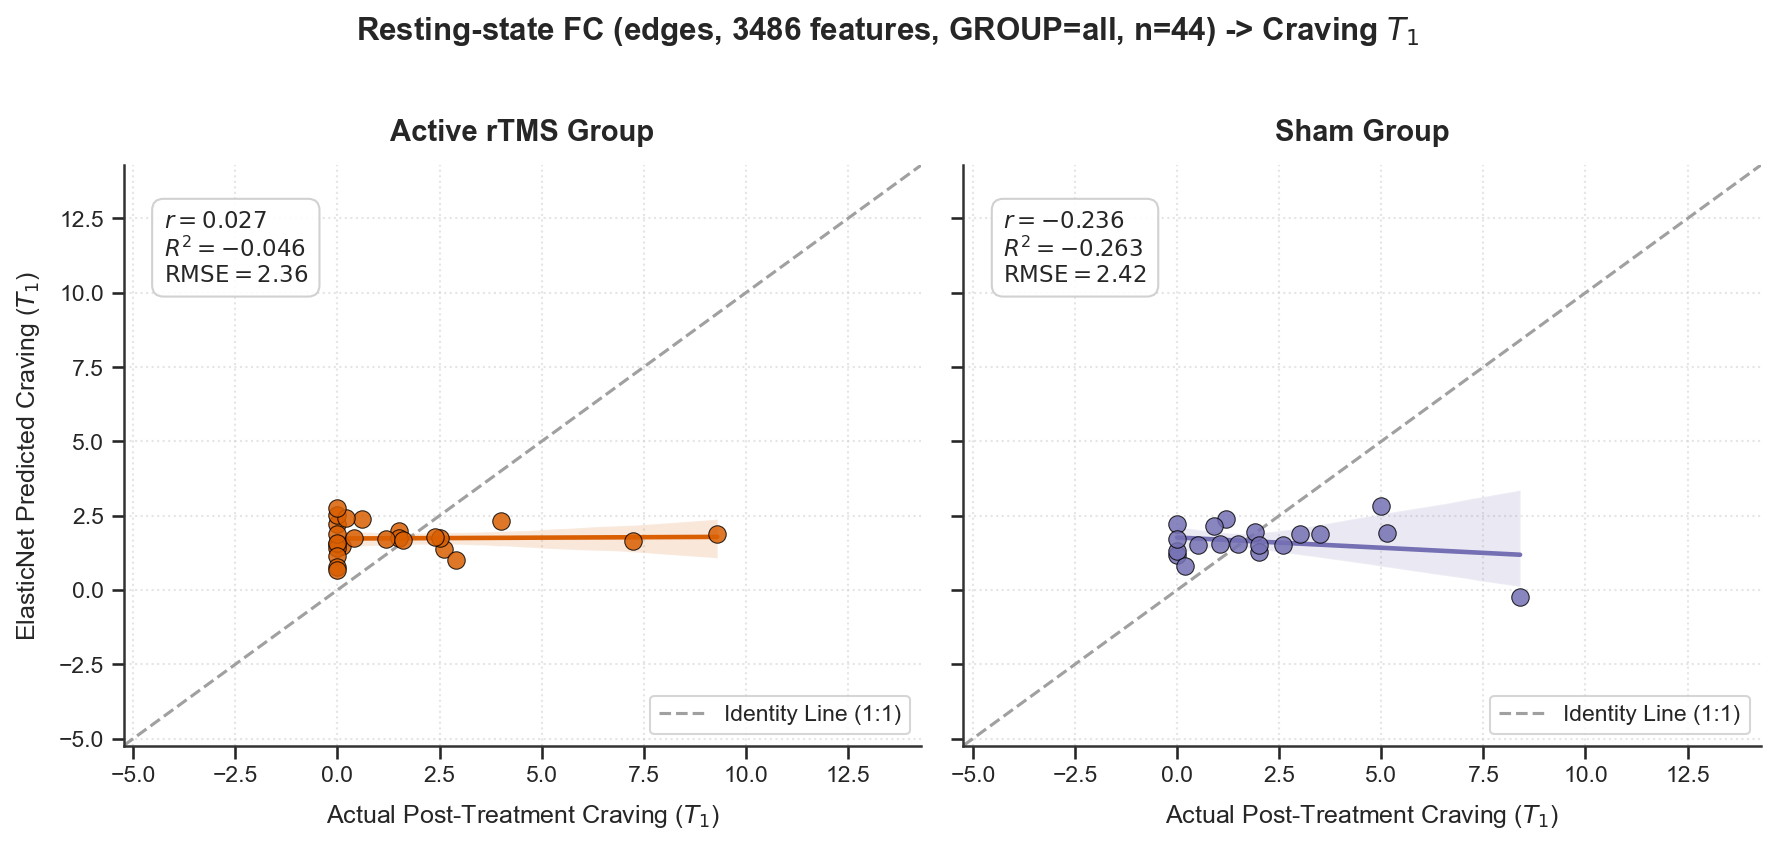

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set clean publication aesthetic
sns.set_theme(style="ticks")
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2

# 1. Map group codes (2 -> Active rTMS, 1 -> Sham)
plot_df = pd.DataFrame({
    'True_Craving': y_true,
    'Pred_Craving': y_pred,
    'Group': np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')
})

# 2. Setup figure canvas
palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'} # High-contrast colorblind-safe palette

# GROUP='active'면 Sham 패널이 비므로 그리지 않는다.
panels = [(g, m) for g, m in [('Active rTMS', m_act), ('Sham', m_shm)] if m is not None]

fig, axes = plt.subplots(1, len(panels), figsize=(6 * len(panels), 5.5),
                         sharex=True, sharey=True, dpi=150, squeeze=False)
axes = axes[0]

# 3. Plot each available group
for i, (grp, m) in enumerate(panels):
    ax = axes[i]
    sub_df = plot_df[plot_df['Group'] == grp]
    color = palette[grp]

    # Draw 1:1 Identity Line (Perfect Prediction)
    min_val = min(plot_df['True_Craving'].min(), plot_df['Pred_Craving'].min()) - 5
    max_val = max(plot_df['True_Craving'].max(), plot_df['Pred_Craving'].max()) + 5
    ax.plot([min_val, max_val], [min_val, max_val], color='#A0A0A0', linestyle='--',
            linewidth=1.5, label='Identity Line (1:1)', zorder=1)

    # Scatter points for actual vs. predicted values
    sns.scatterplot(
        data=sub_df, x='True_Craving', y='Pred_Craving',
        color=color, s=70, alpha=0.85, edgecolor='black', linewidth=0.5, ax=ax, zorder=3
    )

    # Linear Regression Fit with 95% Confidence Interval
    sns.regplot(
        data=sub_df, x='True_Craving', y='Pred_Craving',
        ax=ax, scatter=False, color=color, line_kws={'linewidth': 2.2}, ci=95
    )

    # Formatting & Subgroup Titles
    ax.set_title(f'{grp} Group', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Actual Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)
    if i == 0:
        ax.set_ylabel('ElasticNet Predicted Craving ($T_1$)', fontsize=12, labelpad=8)

    # Annotate statistical metrics inside each plot
    stats_text = f"$r = {m['r']:.3f}$\n$R^2 = {m['r2']:.3f}$\n$\\mathrm{{RMSE}} = {m['rmse']:.2f}$"
    ax.text(
        0.05, 0.80, stats_text, transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#CCCCCC')
    )

    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.grid(True, linestyle=':', alpha=0.5)

fig.suptitle(f'Resting-state FC ({FEATURE_SET}, {len(fc_features)} features, '
             f'GROUP={GROUP}, n={len(df)}) -> Craving $T_1$',
             fontsize=15, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()

# Save high-res figure (파일명에 설정을 넣어 각 조합이 서로 덮어쓰지 않게 한다)
plt.savefig(f'SUDMEX_FC_ENet_{FEATURE_SET}_{GROUP}.png', dpi=300, bbox_inches='tight')
plt.show()